In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

All libraries loaded ✓


In [2]:
df = pd.read_csv('CC GENERAL.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (8950, 18)

Column Names:
 ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Drop customer ID (not useful for clustering)
df.drop(columns=['CUST_ID'], inplace=True)

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing values with column median
imputer = SimpleImputer(strategy='median')
df_clean = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\nAfter cleaning - any nulls?", df_clean.isnull().sum().sum())
print("Dataset ready ✓")

Missing values:
 BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

After cleaning - any nulls? 0
Dataset ready ✓


In [4]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

print("Feature scaling complete ✓")
print("Scaled array shape:", df_scaled.shape)

Feature scaling complete ✓
Scaled array shape: (8950, 17)


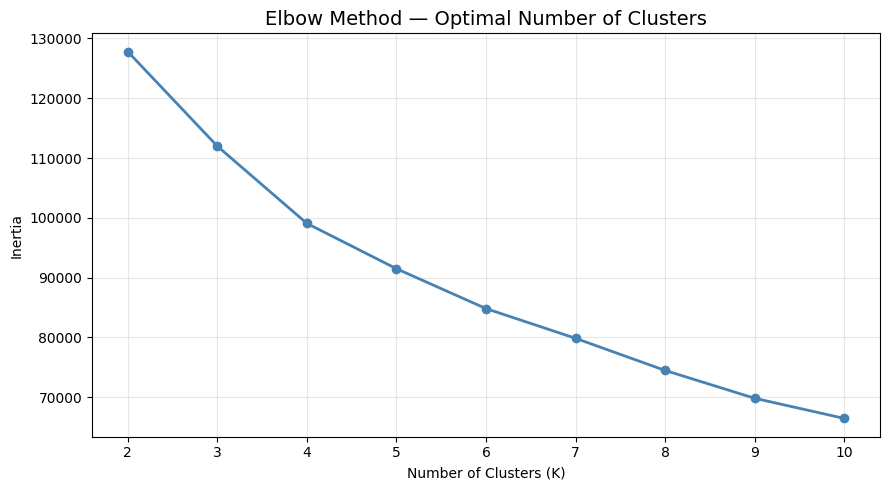

Look for the 'elbow' — where the curve bends. That's your K.


In [5]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_chart.png', dpi=150)
plt.show()
print("Look for the 'elbow' — where the curve bends. That's your K.")

In [6]:
K = 4  # adjust if your elbow chart suggests otherwise

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(df_scaled)

print("Clustering complete ✓")
print("\nCustomers per cluster:")
print(df_clean['Cluster'].value_counts().sort_index())

Clustering complete ✓

Customers per cluster:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


In [7]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_clean['Cluster']

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained by 2 components: 47.6%


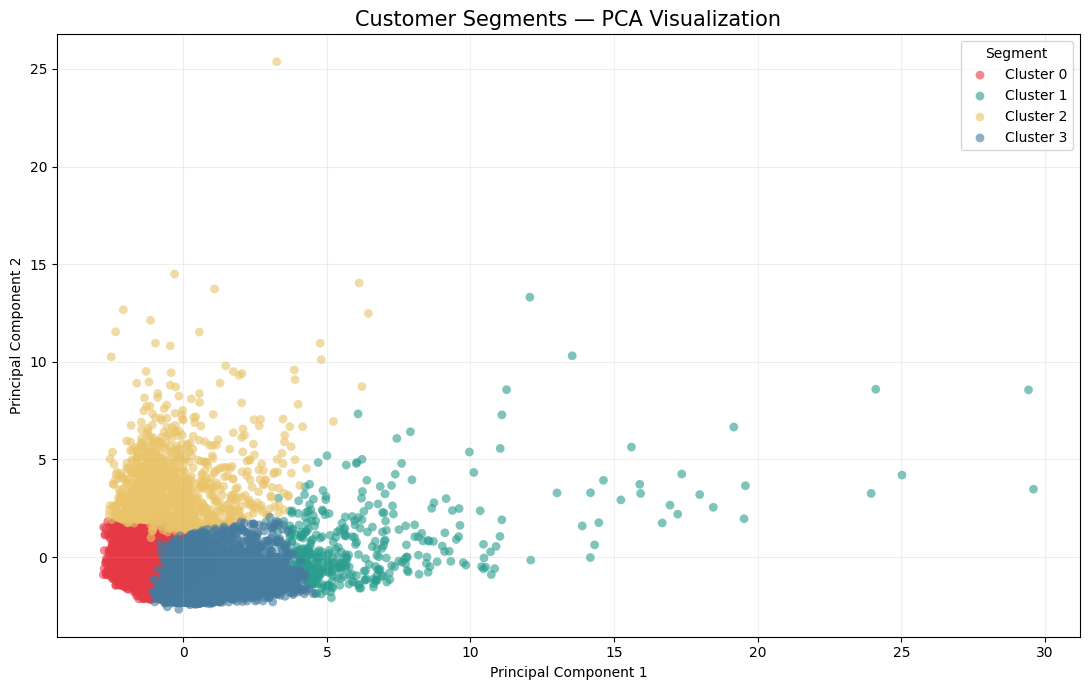

In [8]:
colors = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(11, 7))
for i in range(K):
    mask = df_pca['Cluster'] == i
    plt.scatter(df_pca.loc[mask, 'PC1'],
                df_pca.loc[mask, 'PC2'],
                c=colors[i], label=labels[i],
                alpha=0.6, s=40, edgecolors='none')

plt.title('Customer Segments — PCA Visualization', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Segment', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150)
plt.show()

In [9]:
# Profile each cluster by key metrics
profile_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 
                'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']

cluster_profile = df_clean.groupby('Cluster')[profile_cols].mean().round(2)
print("=== CLUSTER PROFILES ===\n")
print(cluster_profile)

# Assign business labels based on profiles
# (These will match your data — you may swap labels after reviewing your output)
segment_labels = {
    0: '🔴 High Risk — Revolvers',
    1: '🟢 High Value — Full Payers',
    2: '🟡 Moderate — Occasional Spenders',
    3: '🔵 Low Engagement — Dormant'
}

df_clean['Segment'] = df_clean['Cluster'].map(segment_labels)

print("\n=== SEGMENT DISTRIBUTION ===")
print(df_clean['Segment'].value_counts())

=== CLUSTER PROFILES ===

         BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS  \
Cluster                                                                 
0        1012.66     270.04       3278.64    974.26            553.90   
1        3551.15    7681.62       9696.94   7288.74           1972.77   
2        4602.45     501.86       7546.16   3484.05           2003.67   
3         894.91    1236.18       4213.21   1332.19            639.68   

         PRC_FULL_PAYMENT  
Cluster                    
0                    0.08  
1                    0.29  
2                    0.03  
3                    0.27  

=== SEGMENT DISTRIBUTION ===
Segment
🔴 High Risk — Revolvers             3977
🔵 Low Engagement — Dormant          3367
🟡 Moderate — Occasional Spenders    1197
🟢 High Value — Full Payers           409
Name: count, dtype: int64


In [10]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           BUSINESS INSIGHT SUMMARY                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🟢 HIGH VALUE — FULL PAYERS                                 ║
║     → Loyalty rewards, credit limit increase offers         ║
║     → Target for premium card upgrades                      ║
║                                                              ║
║  🔴 HIGH RISK — REVOLVERS                                    ║
║     → Monitor closely for delinquency signals               ║
║     → Offer balance consolidation or hardship programs      ║
║     → Flag for collections review if balance grows          ║
║                                                              ║
║  🟡 MODERATE — OCCASIONAL SPENDERS                           ║
║     → Re-engagement campaigns (cashback, bonus points)      ║
║     → Personalized spend category offers                    ║
║                                                              ║
║  🔵 DORMANT — LOW ENGAGEMENT                                 ║
║     → Win-back email campaigns                              ║
║     → Survey for product-fit issues                         ║
║     → Consider account closure review if no activity        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           BUSINESS INSIGHT SUMMARY                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🟢 HIGH VALUE — FULL PAYERS                                 ║
║     → Loyalty rewards, credit limit increase offers         ║
║     → Target for premium card upgrades                      ║
║                                                              ║
║  🔴 HIGH RISK — REVOLVERS                                    ║
║     → Monitor closely for delinquency signals               ║
║     → Offer balance consolidation or hardship programs      ║
║     → Flag for collections review if balance grows          ║
║                                                              ║
║  🟡 MODERATE — OCCASIONAL SPENDERS                           ║
║     → Re-engagement campaigns (cashback, bonus points)      ║
║     → Personalized spend categor

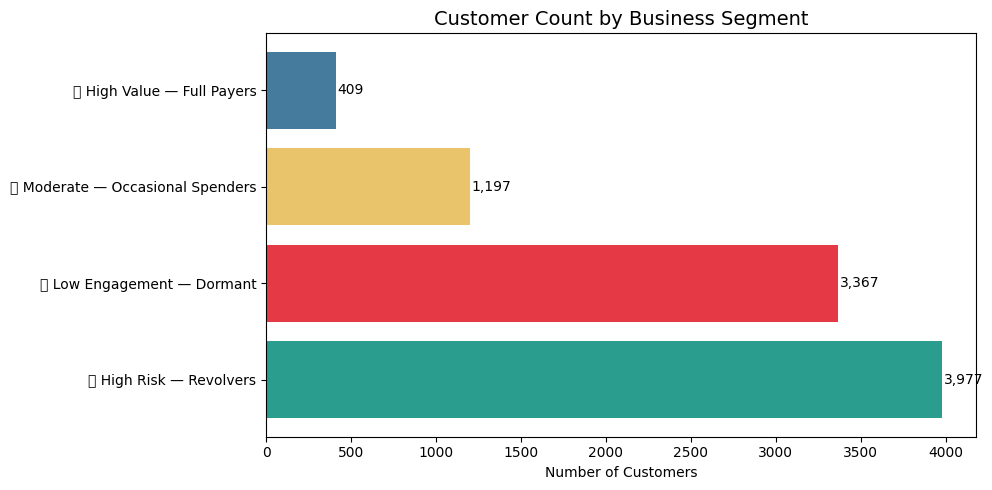


Project complete! Check your folder for 3 saved charts.


In [11]:
segment_counts = df_clean['Segment'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(segment_counts.index, segment_counts.values,
                color=['#2A9D8F', '#E63946', '#E9C46A', '#457B9D'])
plt.title('Customer Count by Business Segment', fontsize=14)
plt.xlabel('Number of Customers')
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150)
plt.show()

print("\nProject complete! Check your folder for 3 saved charts.")

In [12]:
# Export segmented data for Power BI
df_clean.to_csv('customer_segments_output.csv', index=False)
print("File exported ✓ — check your project folder for customer_segments_output.csv")

File exported ✓ — check your project folder for customer_segments_output.csv
